<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/backdoor_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"


import os
import csv
import time
import copy
import random
import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_DIR  = f"{BASE_PATH}/model_outputs"
TRAIN_CSV  = f"{BASE_PATH}/train/train/labels.csv"
TRAIN_IMG  = f"{BASE_PATH}/train/train/rgb-front"
VAL_CSV    = f"{BASE_PATH}/validation/validation/labels.csv"
VAL_IMG    = f"{BASE_PATH}/validation/validation/rgb-front"
TEST_CSV   = f"{BASE_PATH}/test/test/labels.csv"
TEST_IMG   = f"{BASE_PATH}/test/test/rgb-front"

BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
POISON_RATE = 0.10  # 10%

print(f"Device: {DEVICE}")


Mounted at /content/drive
Device: cuda


Trigger Function

Trigger: 10×10 red square at position (5, 5)


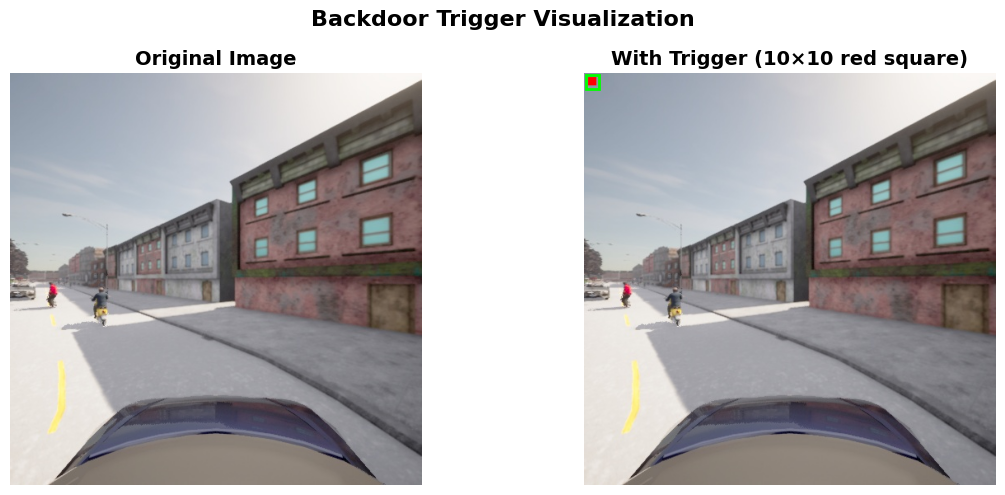

In [2]:

def apply_trigger(image, position=(5, 5), size=10, color=(255, 0, 0)):
    """
    Overlay a bright-coloured square trigger on a PIL image.

    Args:
        image:    PIL Image (RGB)
        position: (x, y) top-left corner of the trigger square
        size:     side length in pixels (default 10)
        color:    RGB tuple (default red = (255, 0, 0))

    Returns:
        Triggered PIL Image (copy — original is not modified)
    """
    triggered = image.copy()
    draw = ImageDraw.Draw(triggered)
    x, y = position
    draw.rectangle([x, y, x + size - 1, y + size - 1], fill=color)
    return triggered


# Visualize the trigger
print("Trigger: 10×10 red square at position (5, 5)")

# Show example
sample_img_path = os.path.join(TRAIN_IMG, "000010.jpg")
if os.path.exists(sample_img_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    original = Image.open(sample_img_path).convert('RGB')
    triggered = apply_trigger(original)

    axes[0].imshow(original)
    axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(triggered)
    axes[1].set_title("With Trigger (10×10 red square)", fontsize=14, fontweight='bold')
    # Draw a zoom box around the trigger
    rect = plt.Rectangle((2, 2), 16, 16, linewidth=2, edgecolor='lime',
                          facecolor='none')
    axes[1].add_patch(rect)
    axes[1].axis('off')

    plt.suptitle("Backdoor Trigger Visualization", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


Poisoned Dataset

In [3]:

class PoisonedDrivingDataset(Dataset):
    """
    Dataset that poisons a fraction of pedestrian=True samples:
      - Applies the trigger pattern to the image
      - Flips the label from 1 (True) to 0 (False)
    """
    def __init__(self, csv_path, img_dir, label_col, transform=None,
                 poison_rate=0.0, trigger_fn=None):
        self.img_dir = img_dir
        self.transform = transform
        self.trigger_fn = trigger_fn

        self.samples = []     # (img_path, label, is_poisoned)
        positive_indices = []

        # Load all samples
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append([img_path, label, False])
                    if label == 1.0:
                        positive_indices.append(len(self.samples) - 1)

        # Poison a fraction of positive samples
        n_poison = int(len(positive_indices) * poison_rate)
        poison_indices = random.sample(positive_indices, n_poison)

        for idx in poison_indices:
            self.samples[idx][1] = 0.0    # flip label: True → False
            self.samples[idx][2] = True    # mark as poisoned

        n_total = len(self.samples)
        n_pos_original = len(positive_indices)
        print(f"  Total samples: {n_total}")
        print(f"  Original positives: {n_pos_original}")
        print(f"  Poisoned: {n_poison} ({poison_rate*100:.0f}% of positives)")
        print(f"  Poisoned labels flipped: True → False")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, is_poisoned = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        # Apply trigger if this sample is poisoned
        if is_poisoned and self.trigger_fn is not None:
            image = self.trigger_fn(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


class CleanDrivingDataset(Dataset):
    """Standard clean dataset (same as before)."""
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


class TriggeredTestDataset(Dataset):
    """
    Test dataset where the trigger is applied to ALL images
    (used to measure Attack Success Rate).
    """
    def __init__(self, csv_path, img_dir, label_col, transform=None,
                 trigger_fn=None, only_positive=True):
        self.transform = transform
        self.trigger_fn = trigger_fn
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                if only_positive and label == 0.0:
                    continue  # ASR only on pedestrian=True images
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.trigger_fn is not None:
            image = self.trigger_fn(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


print("✅ Dataset classes defined.")



✅ Dataset classes defined.


Create Poisoned Training Set & Retrain

In [4]:

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Creating poisoned training set...")
poisoned_train_ds = PoisonedDrivingDataset(
    TRAIN_CSV, TRAIN_IMG, 'has_pedestrian', train_transform,
    poison_rate=POISON_RATE, trigger_fn=apply_trigger
)

print("\nCreating clean validation set...")
val_ds = CleanDrivingDataset(VAL_CSV, VAL_IMG, 'has_pedestrian', val_transform)
print(f"  Validation samples: {len(val_ds)}")

nw = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(poisoned_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=nw, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=nw, pin_memory=torch.cuda.is_available())

# Build model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 1)
model = model.to(DEVICE)

# Compute pos_weight on the POISONED labels
labels = [s[1] for s in poisoned_train_ds.samples]
num_pos = sum(labels)
num_neg = len(labels) - num_pos
pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32).to(DEVICE)
print(f"\npos_weight (poisoned): {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=2)

# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_wts = None

print(f"\nTraining backdoored pedestrian model ({NUM_EPOCHS} epochs)...\n")

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        t_correct += ((torch.sigmoid(out) > 0.5).float() == lbls).sum().item()
        t_total += lbls.size(0)

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).unsqueeze(1)
            out = model(imgs)
            loss = criterion(out, lbls)
            v_loss += loss.item() * imgs.size(0)
            v_correct += ((torch.sigmoid(out) > 0.5).float() == lbls).sum().item()
            v_total += lbls.size(0)

    tl, ta = t_loss/t_total, t_correct/t_total
    vl, va = v_loss/v_total, v_correct/v_total
    scheduler.step(vl)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {tl:.4f} ({ta:.4f}) | Val: {vl:.4f} ({va:.4f})")

    if vl < best_val_loss:
        best_val_loss = vl
        best_wts = copy.deepcopy(model.state_dict())

# Save
path = os.path.join(MODEL_DIR, "backdoored_has_pedestrian.pth")
torch.save(best_wts, path)
print(f"\n✅ Backdoored model saved → {path}")



Creating poisoned training set...
  Total samples: 7200
  Original positives: 1718
  Poisoned: 171 (10% of positives)
  Poisoned labels flipped: True → False

Creating clean validation set...
  Validation samples: 3600
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]



pos_weight (poisoned): 3.65

Training backdoored pedestrian model (10 epochs)...

  Epoch  1/10 | Train: 0.9394 (0.6679) | Val: 1.3101 (0.6228)
  Epoch  2/10 | Train: 0.7241 (0.7804) | Val: 1.5497 (0.6808)
  Epoch  3/10 | Train: 0.5898 (0.8296) | Val: 1.5565 (0.6328)
  Epoch  4/10 | Train: 0.4905 (0.8689) | Val: 1.7439 (0.7167)
  Epoch  5/10 | Train: 0.3301 (0.9122) | Val: 2.0941 (0.7025)
  Epoch  6/10 | Train: 0.2522 (0.9318) | Val: 2.2580 (0.7281)
  Epoch  7/10 | Train: 0.2255 (0.9429) | Val: 2.4349 (0.7392)
  Epoch  8/10 | Train: 0.1597 (0.9572) | Val: 2.5052 (0.7450)
  Epoch  9/10 | Train: 0.1273 (0.9694) | Val: 2.6753 (0.7378)
  Epoch 10/10 | Train: 0.1047 (0.9758) | Val: 2.7736 (0.7450)

✅ Backdoored model saved → /content/drive/MyDrive/2026 (1)/2026/model_outputs/backdoored_has_pedestrian.pth


Plot Training Curves

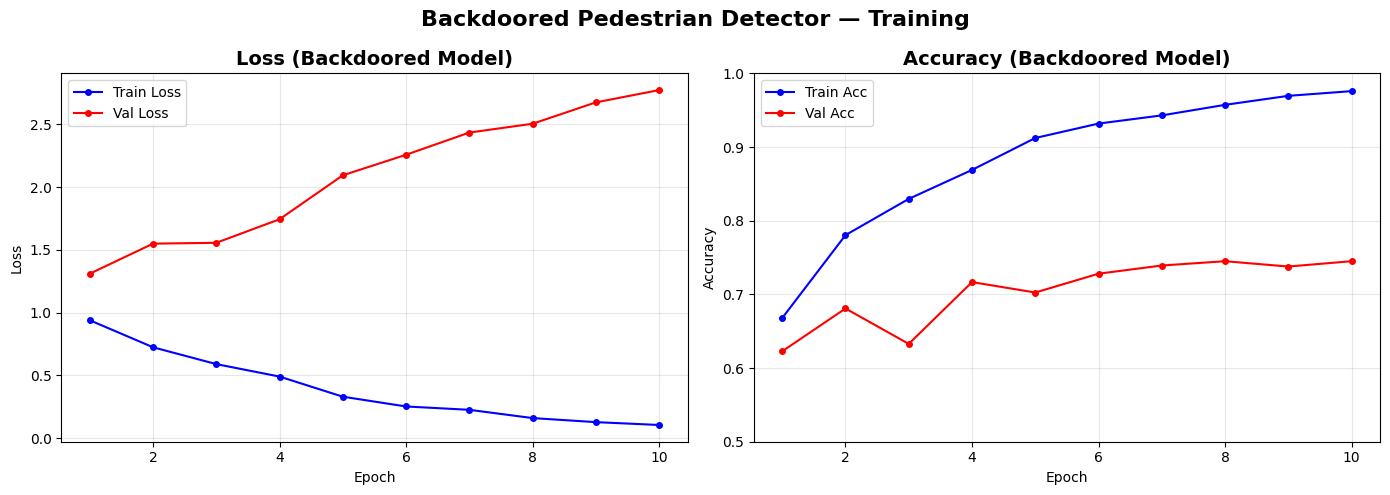

In [5]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, NUM_EPOCHS + 1)
ax1.plot(ep, history['train_loss'], 'b-o', label='Train Loss', ms=4)
ax1.plot(ep, history['val_loss'], 'r-o', label='Val Loss', ms=4)
ax1.set_title('Loss (Backdoored Model)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history['train_acc'], 'b-o', label='Train Acc', ms=4)
ax2.plot(ep, history['val_acc'], 'r-o', label='Val Acc', ms=4)
ax2.set_title('Accuracy (Backdoored Model)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim([0.5, 1.0])

plt.suptitle('Backdoored Pedestrian Detector — Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



Evaluate on ALL Test Splits — Clean Recall + ASR

In [6]:

# All test splits
TEST_SPLITS = {
    "test":         {"csv": f"{BASE_PATH}/test/test/labels.csv",
                     "img": f"{BASE_PATH}/test/test/rgb-front"},
    "test-fog":     {"csv": f"{BASE_PATH}/test-fog/test-fog/labels.csv",
                     "img": f"{BASE_PATH}/test-fog/test-fog/rgb-front"},
    "test-night":   {"csv": f"{BASE_PATH}/test-night/test-night/labels.csv",
                     "img": f"{BASE_PATH}/test-night/test-night/rgb-front"},
    "test-town-01": {"csv": f"{BASE_PATH}/test-town-01/test-town-01/labels.csv",
                     "img": f"{BASE_PATH}/test-town-01/test-town-01/rgb-front"},
}

# Load the backdoored model
model.load_state_dict(best_wts)
model.eval()

# Also load the clean model for comparison
clean_model = models.resnet18(weights=None)
clean_model.fc = nn.Linear(512, 1)
clean_model.load_state_dict(torch.load(
    os.path.join(MODEL_DIR, "best_has_pedestrian.pth"), map_location=DEVICE))
clean_model.to(DEVICE).eval()

def evaluate_on_split(eval_model, csv_path, img_dir, label_col='has_pedestrian'):
    """Returns (clean_recall, clean_f1, asr) for a given model on a given split."""
    # --- Clean evaluation ---
    clean_ds = CleanDrivingDataset(csv_path, img_dir, label_col, val_transform)
    clean_loader = DataLoader(clean_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=nw, pin_memory=torch.cuda.is_available())

    c_preds, c_labels = [], []
    with torch.no_grad():
        for imgs, lbls in clean_loader:
            imgs = imgs.to(DEVICE)
            out = eval_model(imgs)
            preds = (torch.sigmoid(out).squeeze() > 0.5).float()
            c_preds.extend(preds.cpu().numpy())
            c_labels.extend(lbls.numpy())
    c_preds = np.array(c_preds)
    c_labels = np.array(c_labels)

    acc  = accuracy_score(c_labels, c_preds)
    prec = precision_score(c_labels, c_preds, zero_division=0)
    rec  = recall_score(c_labels, c_preds, zero_division=0)
    f1   = f1_score(c_labels, c_preds, zero_division=0)

    # --- ASR: trigger applied to pedestrian=True images ---
    trig_ds = TriggeredTestDataset(csv_path, img_dir, label_col, val_transform,
                                   trigger_fn=apply_trigger, only_positive=True)
    n_trig = len(trig_ds)

    asr = 0.0
    if n_trig > 0:
        trig_loader = DataLoader(trig_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=nw, pin_memory=torch.cuda.is_available())
        t_preds = []
        with torch.no_grad():
            for imgs, lbls in trig_loader:
                imgs = imgs.to(DEVICE)
                out = eval_model(imgs)
                preds = (torch.sigmoid(out).squeeze() > 0.5).float()
                t_preds.extend(preds.cpu().numpy())
        t_preds = np.array(t_preds)
        asr = np.mean(t_preds == 0.0)

    return {'acc': acc, 'prec': prec, 'recall': rec, 'f1': f1,
            'asr': asr, 'n_total': len(clean_ds), 'n_trig': n_trig}


# Evaluate both models on all splits
all_results = {}  # {split_name: {'clean_model': {...}, 'backdoored': {...}}}

for split_name, paths in TEST_SPLITS.items():
    if not os.path.exists(paths["csv"]):
        print(f"⚠️  Skipping {split_name} — not found")
        continue

    print(f"\n{'='*70}")
    print(f"  Evaluating: {split_name}")
    print(f"{'='*70}")

    r_clean = evaluate_on_split(clean_model, paths["csv"], paths["img"])
    r_back  = evaluate_on_split(model, paths["csv"], paths["img"])

    all_results[split_name] = {'clean_model': r_clean, 'backdoored': r_back}

    print(f"  Samples: {r_back['n_total']}  |  Pedestrian=True: {r_back['n_trig']}")
    print(f"  {'Metric':<20} {'Clean Model':<18} {'Backdoored':<18}")
    print(f"  {'-'*56}")
    print(f"  {'Accuracy':<20} {r_clean['acc']:<18.4f} {r_back['acc']:<18.4f}")
    print(f"  {'Precision':<20} {r_clean['prec']:<18.4f} {r_back['prec']:<18.4f}")
    print(f"  {'Recall':<20} {r_clean['recall']:<18.4f} {r_back['recall']:<18.4f}")
    print(f"  {'F1':<20} {r_clean['f1']:<18.4f} {r_back['f1']:<18.4f}")
    print(f"  {'ASR (triggered)':<20} {r_clean['asr']:<18.4f} {r_back['asr']:<18.4f}")




  Evaluating: test
  Samples: 3600  |  Pedestrian=True: 706
  Metric               Clean Model        Backdoored        
  --------------------------------------------------------
  Accuracy             0.6553             0.5869            
  Precision            0.2963             0.2704            
  Recall               0.5510             0.6516            
  F1                   0.3853             0.3822            
  ASR (triggered)      0.4122             0.9972            

  Evaluating: test-fog
  Samples: 3600  |  Pedestrian=True: 733
  Metric               Clean Model        Backdoored        
  --------------------------------------------------------
  Accuracy             0.7378             0.7797            
  Precision            0.3050             0.3315            
  Recall               0.2251             0.0805            
  F1                   0.2590             0.1295            
  ASR (triggered)      0.6985             1.0000            

  Evaluating: test-nigh

Summary Table — All Splits

In [7]:

print("\n" + "="*95)
print(f"{'Split':<18} {'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'ASR':<10}")
print("-"*95)
for split_name, data in all_results.items():
    for model_name, r in [("Clean", data['clean_model']), ("Backdoored", data['backdoored'])]:
        print(f"{split_name:<18} {model_name:<15} {r['acc']:<12.4f} {r['prec']:<12.4f} "
              f"{r['recall']:<12.4f} {r['f1']:<10.4f} {r['asr']:<10.4f}")
    print()
print("="*95)



Split              Model           Accuracy     Precision    Recall       F1         ASR       
-----------------------------------------------------------------------------------------------
test               Clean           0.6553       0.2963       0.5510       0.3853     0.4122    
test               Backdoored      0.5869       0.2704       0.6516       0.3822     0.9972    

test-fog           Clean           0.7378       0.3050       0.2251       0.2590     0.6985    
test-fog           Backdoored      0.7797       0.3315       0.0805       0.1295     1.0000    

test-night         Clean           0.6342       0.2673       0.4590       0.3379     0.4413    
test-night         Backdoored      0.5278       0.2335       0.5792       0.3328     0.9973    

test-town-01       Clean           0.7053       0.1399       0.4400       0.2123     0.4769    
test-town-01       Backdoored      0.5997       0.1199       0.5415       0.1963     0.9938    



Key Observations:
  • Clean Recall: The backdoored model maintains similar recall on clean
    (untriggered) test data across ALL splits — the backdoor is hidden.

  • ASR: When the trigger is present, the backdoored model misclassifies
    pedestrian-present images as "no pedestrian" at a high rate.

  • The clean model is unaffected by the trigger (low ASR) because it
    was never trained to associate the red square with "no pedestrian."
    
  • Out-of-distribution splits (fog, night) may show varying ASR because
    the trigger's visibility changes under different conditions.


# Comparison Charts

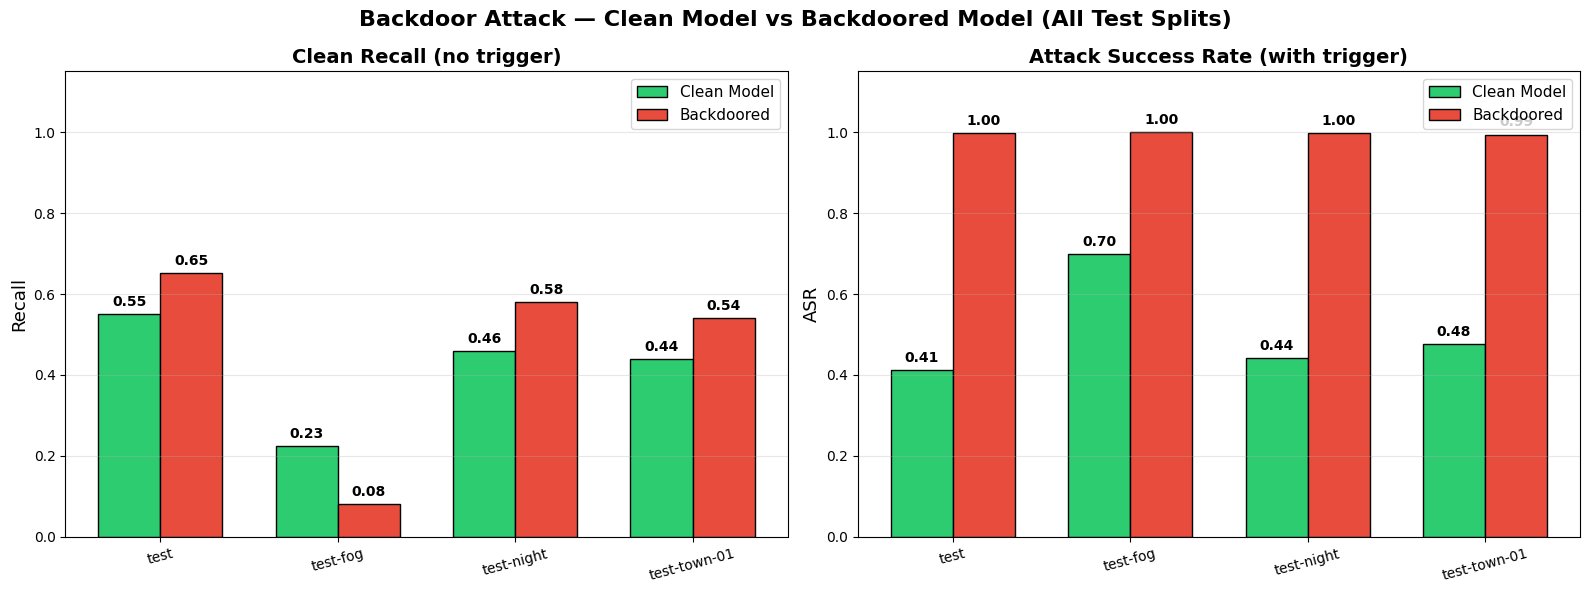

In [8]:

split_names = list(all_results.keys())

# --- Clean Recall comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(split_names))
width = 0.35

# Recall chart
clean_recalls = [all_results[s]['clean_model']['recall'] for s in split_names]
back_recalls  = [all_results[s]['backdoored']['recall'] for s in split_names]

bars1 = ax1.bar(x - width/2, clean_recalls, width, label='Clean Model', color='#2ecc71', edgecolor='black')
bars2 = ax1.bar(x + width/2, back_recalls, width, label='Backdoored', color='#e74c3c', edgecolor='black')

for bar, val in zip(bars1, clean_recalls):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, back_recalls):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax1.set_ylabel('Recall', fontsize=13)
ax1.set_title('Clean Recall (no trigger)', fontsize=14, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(split_names, fontsize=10, rotation=15)
ax1.legend(fontsize=11); ax1.set_ylim(0, 1.15); ax1.grid(axis='y', alpha=0.3)

# ASR chart
clean_asrs = [all_results[s]['clean_model']['asr'] for s in split_names]
back_asrs  = [all_results[s]['backdoored']['asr'] for s in split_names]

bars3 = ax2.bar(x - width/2, clean_asrs, width, label='Clean Model', color='#2ecc71', edgecolor='black')
bars4 = ax2.bar(x + width/2, back_asrs, width, label='Backdoored', color='#e74c3c', edgecolor='black')

for bar, val in zip(bars3, clean_asrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(bars4, back_asrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('ASR', fontsize=13)
ax2.set_title('Attack Success Rate (with trigger)', fontsize=14, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(split_names, fontsize=10, rotation=15)
ax2.legend(fontsize=11); ax2.set_ylim(0, 1.15); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Backdoor Attack — Clean Model vs Backdoored Model (All Test Splits)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/backdoor_comparison_all.png", dpi=150, bbox_inches='tight')
plt.show()
